# physim: getting started

The Rust engine does the stepping; Python sets up systems and analyses results.
Build the extension first (from the repo root): `maturin develop --release`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import physim as ps

ps.INTEGRATORS

['explicit_euler', 'symplectic_euler', 'verlet', 'yoshida4', 'rk4']

## 1. Two-body Kepler problem

Equal masses in the centre-of-mass frame, $G = 1$, sub-circular speed so the orbit is eccentric.

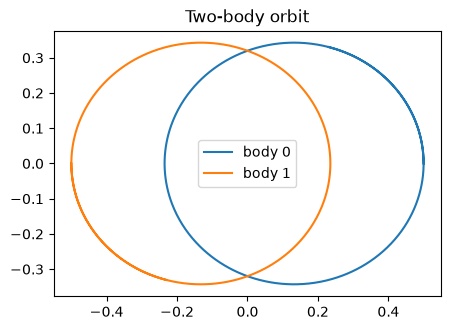

In [2]:
def kepler(integrator):
    w = ps.World(integrator=integrator)
    w.add_particle([0.5, 0, 0], vel=[0, 0.4, 0], mass=0.5)
    w.add_particle([-0.5, 0, 0], vel=[0, -0.4, 0], mass=0.5)
    w.add_force(ps.NewtonianGravity(G=1.0))
    return w

traj = kepler("yoshida4").run(dt=1e-3, steps=5_000, record_every=5)
fig, ax = plt.subplots(figsize=(5, 5))
for p in range(traj.n_particles):
    ax.plot(traj.pos[:, p, 0], traj.pos[:, p, 1], label=f"body {p}")
ax.set_aspect("equal"); ax.legend(); ax.set_title("Two-body orbit");

## 2. Integrator comparison: long-time energy error

Same orbit, same $\Delta t = 10^{-2}$, ~25 orbital periods. Symplectic schemes keep the energy
error bounded and oscillating; Euler and RK4 drift secularly.

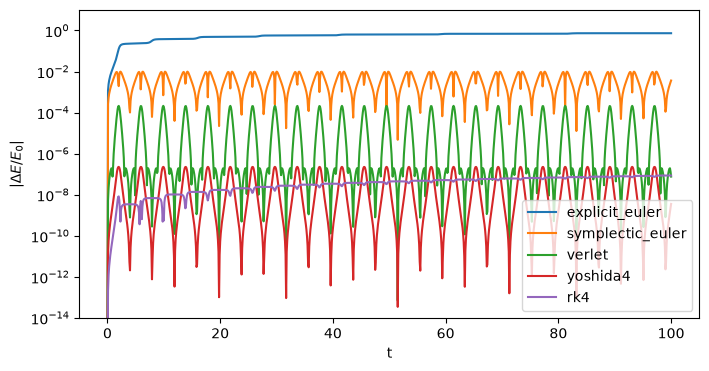

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for name in ps.INTEGRATORS:
    tr = kepler(name).run(dt=1e-2, steps=10_000, record_every=10)
    ax.semilogy(tr.t, np.abs(ps.relative_energy_error(tr)) + 1e-17, label=name)
ax.set_xlabel("t"); ax.set_ylabel(r"$|\Delta E / E_0|$"); ax.legend(); ax.set_ylim(1e-14, 10);

## 3. Convergence order

Global error at $t = 2$ for the unit harmonic oscillator, $x(t) = \cos t$.

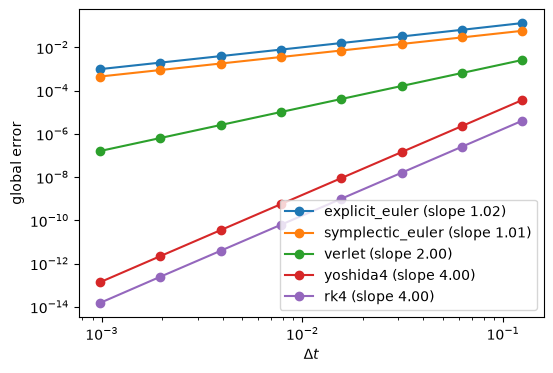

In [4]:
def oscillator_error(name, dt, t_end=2.0):
    w = ps.World(integrator=name)
    w.add_particle([1, 0, 0])
    w.add_force(ps.AnchorSpring(0, anchor=[0, 0, 0], k=1.0))
    w.step(dt, n=round(t_end / dt))
    return np.hypot(w.positions[0, 0] - np.cos(t_end), w.velocities[0, 0] + np.sin(t_end))

dts = 2.0 / 2.0 ** np.arange(4, 12)  # divides t_end exactly
fig, ax = plt.subplots(figsize=(6, 4))
for name in ps.INTEGRATORS:
    err = [oscillator_error(name, dt) for dt in dts]
    slope = np.polyfit(np.log(dts[:4]), np.log(err[:4]), 1)[0]  # skip round-off floor
    ax.loglog(dts, err, "o-", label=f"{name} (slope {slope:.2f})")
ax.set_xlabel(r"$\Delta t$"); ax.set_ylabel("global error"); ax.legend();

## 4. Prototyping new physics in Python: apsidal precession

`CustomForce` takes a Python function `acceleration(t, pos, vel, mass) -> (N, 3)`, so you can try an
idea without touching Rust. Here: a test particle in $V(r) = -k/r + \beta/r^2$ (per unit mass).
The orbit equation becomes $u'' + \gamma^2 u = k/L^2$ with $\gamma = \sqrt{1 + 2\beta/L^2}$, so
periapsis advances by $\Delta\varphi = 2\pi(1/\gamma - 1)$ per radial period, an exact result we can check.
Periapses are found with an `Event` rather than by scanning frames, so they are located far more precisely than
the recording interval.

7 periapses; advance per orbit: measured -0.0431839159 rad, predicted -0.0431839159 rad
relative difference 8.7e-10
max |dE/E0| = 4.6e-12


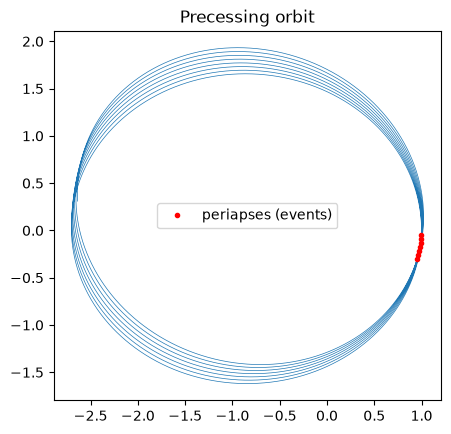

In [5]:
k, beta = 1.0, 0.01

def accel(t, pos, vel, mass):
    r = np.linalg.norm(pos, axis=1, keepdims=True)
    return -k * pos / r**3 + 2 * beta * pos / r**4

def potential(t, pos, mass):
    r = np.linalg.norm(pos, axis=1)
    return float(np.sum(mass * (-k / r + beta / r**2)))

w = ps.World(integrator="yoshida4")
w.add_particle([1.0, 0, 0], vel=[0, 1.2, 0])
w.add_force(ps.CustomForce(accel, potential=potential, velocity_dependent=False))
L = np.cross(w.positions[0], w.velocities[0])[2]

# Periapsis: radial velocity r·v crosses zero upwards. The event is located to ~1e-12 of a step.
periapsis = ps.Event.radial_velocity(0, direction=+1)
tr = w.run(dt=2e-3, steps=60_000, record_every=5, events=[periapsis])
peri = tr.event_pos[:, 0]
phi = np.unwrap(np.arctan2(peri[:, 1], peri[:, 0]))
measured = np.mean(np.diff(phi))  # unwrap folds the 2*pi orbit away: this is the advance itself
predicted = 2 * np.pi * (1 / np.sqrt(1 + 2 * beta / L**2) - 1)
print(f"{len(peri)} periapses; advance per orbit: measured {measured:.10f} rad, predicted {predicted:.10f} rad")
print(f"relative difference {abs(measured / predicted - 1):.1e}")
print(f"max |dE/E0| = {np.max(np.abs(ps.relative_energy_error(tr))):.1e}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(tr.pos[:, 0, 0], tr.pos[:, 0, 1], lw=0.5)
ax.plot(peri[:, 0], peri[:, 1], "r.", label="periapses (events)")
ax.set_aspect("equal"); ax.legend(); ax.set_title("Precessing orbit");

Once an idea works, port the force to Rust (implement `physim::Force`, see the README) to get the
full speed: the Python callback costs a round trip per force evaluation.

## 5. Many particles: waves on a spring chain

60 masses joined by pre-stretched springs (tension $T = k(a - L)$) with fixed ends, released from a small
Gaussian transverse displacement. Linear transverse waves travel at $c = a\sqrt{T/(m a)}$ sites per unit time
and reflect inverted at the fixed ends.

wave speed c = 4.47 sites per unit time


max |dE/E0| = 4.4e-09


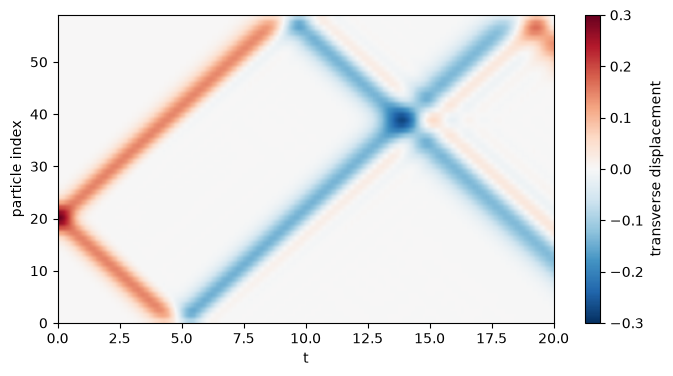

In [6]:
n, spacing, rest, k_s, amp = 60, 1.0, 0.8, 100.0, 0.3
w = ps.World(integrator="verlet")
x = np.arange(n) * spacing
for xi in x:
    w.add_particle([xi, amp * np.exp(-((xi - 20) / 3) ** 2), 0], mass=1.0)
for i in range(n - 1):
    w.add_force(ps.Spring(i, i + 1, k=k_s, rest_length=rest))
w.add_force(ps.AnchorSpring(0, anchor=[-spacing, 0, 0], k=k_s, rest_length=rest))
w.add_force(ps.AnchorSpring(n - 1, anchor=[n * spacing, 0, 0], k=k_s, rest_length=rest))
c = np.sqrt(k_s * (spacing - rest) * spacing / 1.0)
print(f"wave speed c = {c:.2f} sites per unit time")

tr = w.run(dt=1e-3, steps=20_000, record_every=50)
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(tr.pos[:, :, 1].T, aspect="auto", origin="lower", cmap="RdBu_r",
               extent=[tr.t[0], tr.t[-1], 0, n - 1], vmin=-amp, vmax=amp)
ax.set_xlabel("t"); ax.set_ylabel("particle index"); fig.colorbar(im, label="transverse displacement")
print(f"max |dE/E0| = {np.max(np.abs(ps.relative_energy_error(tr))):.1e}")